In [ ]:
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# Convert to numeric (important)
X = X.apply(pd.to_numeric, errors='coerce')
y = y.apply(pd.to_numeric, errors='coerce')

# Remove missing values
combined_df = pd.concat([X, y], axis=1).dropna()

X = combined_df[X.columns]
y = combined_df[y.columns].squeeze().astype(int)

# Convert labels: 2 → 0, 4 → 1
y = y.replace({2: -1, 4: 1})

print("Dataset shape:", X.shape)
print("Labels:", np.unique(y))
X=X.values
y=y.values

Dataset shape: (683, 9)
Labels: [-1  1]


In [ ]:
print(X.shape)


(683, 9)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=25,shuffle=True
)
print(X_train[126])

[4. 2. 4. 3. 2. 2. 2. 1. 1.]


In [ ]:
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
xmin = sc.data_min_
xmax = sc.data_max_
print(xmin)
print(xmax)
X_train_df = pd.DataFrame(X_train)

# Add target column
X_train_df['Target'] = y_train.values if hasattr(y_train, 'values') else y_train

# Print first 5 rows
print(X_train_df.head())


[1. 1. 1. 1. 1. 1. 1. 1. 1.]
[10. 10. 10. 10. 10. 10. 10. 10. 10.]
          0    1         2    3         4         5         6    7    8  \
0  0.444444  1.0  1.000000  1.0  1.000000  0.111111  1.000000  1.0  1.0   
1  0.000000  0.0  0.222222  0.0  0.000000  0.000000  0.111111  0.0  0.0   
2  0.444444  0.0  0.222222  0.0  0.111111  0.000000  0.222222  0.0  0.0   
3  0.000000  0.0  0.000000  0.0  0.000000  0.000000  0.111111  0.0  0.0   
4  0.000000  0.0  0.000000  0.0  0.000000  0.000000  0.111111  0.0  0.0   

   Target  
0       1  
1      -1  
2      -1  
3      -1  
4      -1  


In [ ]:
from sklearn.svm import SVC
svc=SVC(kernel='poly',degree=3,gamma=2)
svc.fit(X_train,y_train)

SVC(gamma=2, kernel='poly')

In [ ]:
y_pred=svc.predict(X_test)

              precision    recall  f1-score   support

          -1       0.97      0.96      0.96        96
           1       0.90      0.93      0.92        41

    accuracy                           0.95       137
   macro avg       0.94      0.94      0.94       137
weighted avg       0.95      0.95      0.95       137



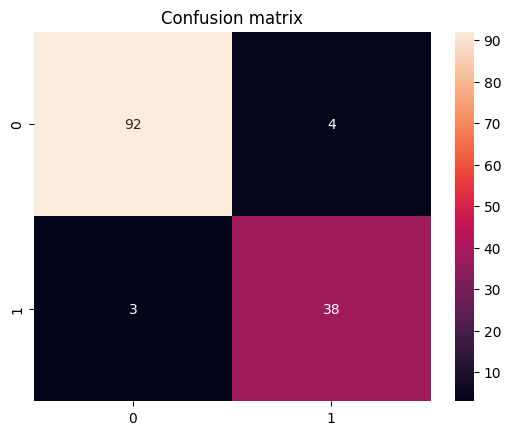

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d').set_title('Confusion matrix')
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.98      0.99      0.99       348
           1       0.99      0.97      0.98       198

    accuracy                           0.99       546
   macro avg       0.99      0.98      0.98       546
weighted avg       0.99      0.99      0.99       546



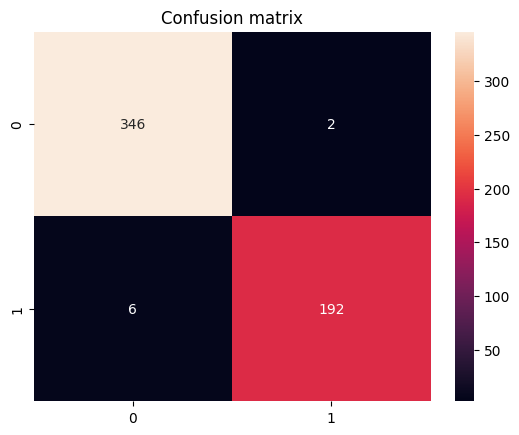

In [ ]:
y_pred_train=svc.predict(X_train)
cm=confusion_matrix(y_train,y_pred_train)
sns.heatmap(cm,annot=True,fmt='d').set_title('Confusion matrix')
print(classification_report(y_train,y_pred_train))

In [ ]:
svc.get_params()
print(svc.n_support_)

[15 28]


In [ ]:
decision_function=svc.decision_function(X_test)
print(decision_function)

[ 5.60076247 -1.38641688 -1.42747685 -1.41519771 -1.46311597 -1.31478376
 -1.41387849  1.78429026  4.72948208 -1.41688042 -1.48507311 -1.42598795
 -1.72735101 -1.36747438 -1.41027676 -1.40767036  4.5555991   2.76053233
 -1.34379446  3.11788345 -1.37675673 -1.40836591 -1.20897032  0.98450127
  8.0003976  -0.9548705   2.22282093 -1.47537685 -1.38239327  7.69679153
 -1.41768149 13.73451399  5.14899172 -1.4109152  15.40891418 -1.41136917
 -1.42262829  6.39112756 -1.32375908 -1.4172241  -1.41773225  0.83349099
 -1.42747685  2.08901798  8.01948427 -1.38603447 -1.0365264   8.76620779
 -1.41485471 10.13008265 -1.42785583 -1.35014289 -1.43767782 -1.42624842
 -1.32562557 -1.40127864 -1.41485471 -1.39737596  0.82780214  0.27061494
 -1.42747685 -1.38284619 -1.41519771 -1.41080299  0.46918729  4.79420635
 -1.42747685 -1.38603447  2.28841518 -1.39862314 -1.41768149  5.62440459
 -1.41768149  3.71549376 12.57622243 -1.39862314  8.99417487 -1.35743832
 -0.11537302 -1.42238474 -1.38603447  3.7212367   5

In [ ]:
print("svc.gamma: ",svc.gamma)
print("svc.degree",svc.degree)
sv=open("support_vectors_polybreast.txt","w")
dual_coeff=open("dual_coeff_polybreast.txt","w")
intercept=open("intercept_polybreast.txt","w")
x_min="xmin_polybreast.txt"
x_max="xmax_polybreast.txt"
np.savetxt(sv,svc.support_vectors_)
np.savetxt(dual_coeff,svc.dual_coef_,delimiter=' ')
np.savetxt(intercept,svc.intercept_,delimiter=' ')
np.savetxt(x_min,xmin,delimiter=' ')
np.savetxt(x_max,xmax,delimiter=' ')

sv.close()
dual_coeff.close()
intercept.close()

svc.gamma:  2
svc.degree 3


In [ ]:
decision_value = svc.decision_function([X_train[126]])
print(decision_value)

[-1.06423399]


In [ ]:
print("Support vectors shape:", svc.support_vectors_.shape)
print("Dual coef shape:", svc.dual_coef_.shape)

Support vectors shape: (43, 9)
Dual coef shape: (1, 43)


In [ ]:
print(svc.coef0)
print(X.shape[1])
print(X_train[126])

0.0
9
[0.33333333 0.11111111 0.33333333 0.22222222 0.11111111 0.11111111
 0.11111111 0.         0.        ]


In [ ]:
from sklearn.metrics import recall_score,precision_score,f1_score
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.9047619047619048
0.926829268292683
0.9156626506024096
